In [97]:
import sys
sys.path.insert(0, "..")

from pathlib import Path
from analysis.loaders import (load_session, load_trials, load_stims,
                              session_info, load_video_timestamps, response_times)

In [98]:
data_dir = Path("/Users/hakan/Library/CloudStorage/Dropbox/Hakan/lab/data/cheese_data/ASD110/ASD110_20260804/ASD110_20260804_001")

In [99]:
# Per-trial structured array (all scalar datasets)
trials = load_trials(data_dir)

In [100]:
# Consolidated single-file HDF5 (format_version 2): trials, stimulus plan, per-device data,
# camera timestamps and metadata are all in the one .h5. load_session returns a nested dict
# by group, with the root metadata (was metadata.yaml) under "attrs".
data = load_session(data_dir)
info = session_info(data_dir)
print("session:", info["session_id"], "| groups:", info["groups"])
print(f"{info['n_trials']} trials | {info.get('duration_s', 0)/60:.1f} min | "
      f"hit rate {info.get('hit_rate', float('nan')):.2f} | "
      f"{info.get('total_rewards_ul', 0):.0f} uL total")

attrs = data["attrs"]                          # session metadata incl. the full task_config
print("\nlevel:", attrs.get("level"), "| saved devices:", attrs.get("saved_devices"))
print("stimulus plan:", [k for k in data.get("stimulus", {}) if k != "_attrs"])
# groups: data["trials"], data["stimulus"], data["lick"], data["reward"],
#         data["photodiode"], data["camera"]  (present per saved device)

session: ASD110_20260804_001 | groups: ['lick', 'photodiode', 'reward', 'stimulus', 'trials']
50 trials | 35.2 min | hit rate 0.52 | 400 uL total

level: 1 | saved devices: ['calibration_probe', 'camera', 'lick_sensor', 'photodiode', 'reward']
stimulus plan: ['block_delays', 'block_start_indices', 'duration_s', 'iti_planned_s', 'poststim_s', 'prestim_s', 'px_size', 'px_x', 'px_y', 'stim_alt_deg']


in-window hits: 26/50   recorded any-lick hits: 26/50


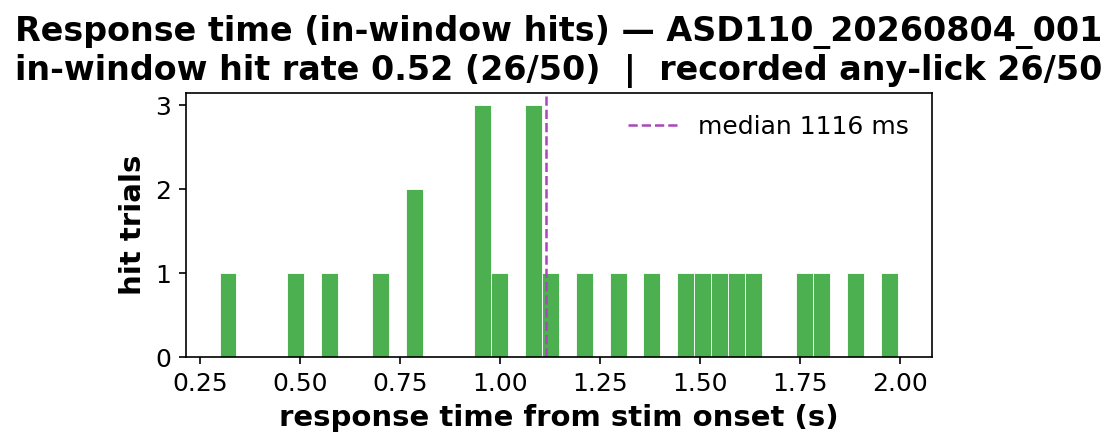

In [101]:
# Response-time histogram. HIT = a lick within the response window (analysis-side definition,
# stricter than the recorded trial_outcome, which counts a lick anywhere in the trial). RT is
# the first-lick latency from stimulus onset (photodiode-corrected true_onset_t).
import numpy as np
import matplotlib.pyplot as plt

rt = response_times(data_dir, ref="onset", within_window=True)   # NaN unless licked in-window
hit = np.isfinite(rt)                                            # in-window responders = hits
rt_hit = rt[hit]
trials = load_trials(data_dir)
rec_hit = int((trials["trial_outcome"] == "hit").sum())          # recorded (any-lick) hits
n = len(trials)

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(rt_hit, bins=40, color="#4caf50", edgecolor="white", linewidth=0.4)
if rt_hit.size:
    ax.axvline(np.median(rt_hit), color="#ab47bc", ls="--", lw=1.2,
               label=f"median {np.median(rt_hit)*1e3:.0f} ms")
    ax.legend(frameon=False)
ax.set_xlabel("response time from stim onset (s)")
ax.set_ylabel("hit trials")
ax.set_title(f"Response time (in-window hits) — {info['session_id']}\n"
             f"in-window hit rate {hit.mean():.2f} ({hit.sum()}/{n})  |  "
             f"recorded any-lick {rec_hit}/{n}")
fig.tight_layout()
print(f"in-window hits: {hit.sum()}/{n}   recorded any-lick hits: {rec_hit}/{n}")

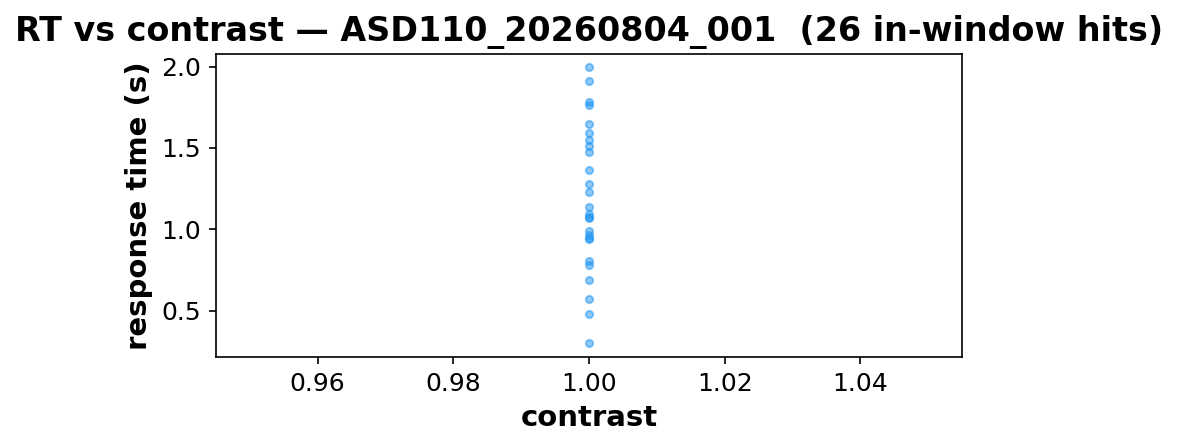

In [102]:
# Response time vs a trial variable — does RT depend on it? Set COND to "contrast" or "stim_az_deg".
import numpy as np
import matplotlib.pyplot as plt

COND = "contrast"                                   # or "stim_az_deg"
rt = response_times(data_dir, ref="onset", within_window=True)
trials = load_trials(data_dir)
x = trials[COND].astype(float)
ok = np.isfinite(rt)
xv, rv = x[ok], rt[ok]
groups = sorted(np.unique(xv))

fig, ax = plt.subplots(figsize=(6, 3.2))
if 1 < len(groups) <= 12:                           # discrete conditions -> box + median trend
    grouped = [rv[xv == g] for g in groups]
    ax.boxplot(grouped, positions=range(len(groups)), widths=0.5, showfliers=False)
    ax.plot(range(len(groups)), [np.median(d) if len(d) else np.nan for d in grouped],
            "-o", color="#2196f3")
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels([f"{g:g}" for g in groups])
else:                                               # continuous / single value -> scatter
    ax.scatter(xv, rv, s=12, alpha=0.5, color="#2196f3")
ax.set_xlabel(COND); ax.set_ylabel("response time (s)")
ax.set_title(f"RT vs {COND} — {info['session_id']}  ({rv.size} in-window hits)")
fig.tight_layout()

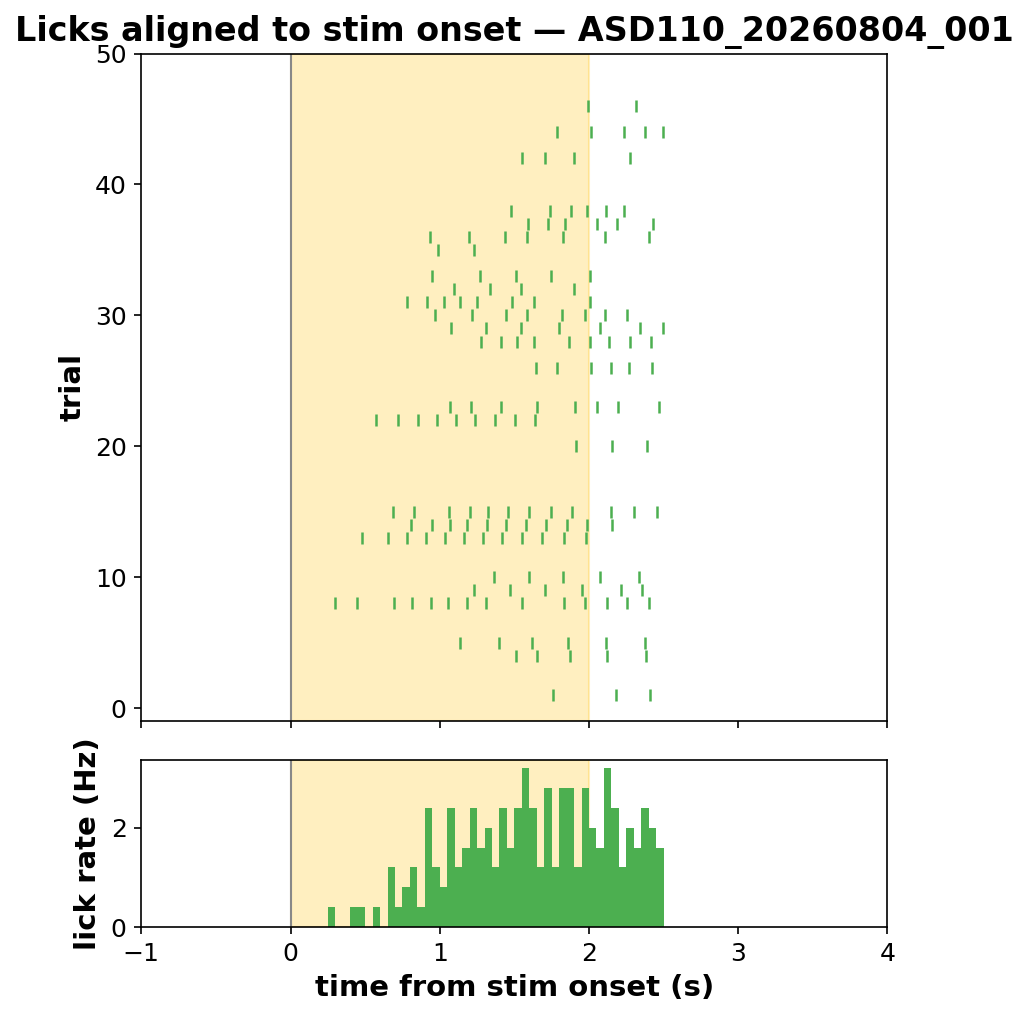

In [103]:
# Lick raster + PSTH aligned to stimulus onset (onset = 0). Uses the /lick group; the amber
# band is the response window (resp_delay .. resp_delay + response_window).
import numpy as np
import matplotlib.pyplot as plt

data = load_session(data_dir)
lick_times = data.get("lick", {}).get("lick_times")
onset = np.asarray(data["trials"]["true_onset_t"], float)
onset = np.where(np.isfinite(onset), onset, np.asarray(data["trials"]["stim_onset_t"], float))
rcfg = (data["attrs"].get("task_config") or {}).get("reward", {})
resp_delay = float(rcfg.get("resp_delay_s", rcfg.get("reward_delay_s", 0.6)))
resp_win = float(rcfg.get("response_window", 1.4))

if lick_times is None:
    print("no /lick group (lick device not saved) — nothing to raster")
else:
    W = (-1.0, 4.0)   # window around onset (s)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7), sharex=True,
                                   gridspec_kw={"height_ratios": [4, 1]})
    all_rel = []
    for i, lt in enumerate(lick_times):
        rel = np.asarray(lt, float) - onset[i]
        rel = rel[(rel >= W[0]) & (rel <= W[1])]
        all_rel.append(rel)
        ax1.plot(rel, np.full_like(rel, i), "|", color="#4caf50", ms=6, mew=1.2)
    for ax in (ax1, ax2):
        ax.axvspan(resp_delay, resp_delay + resp_win, color="#ffc107", alpha=0.25)  # response window
        ax.axvline(0, color="#888", lw=1)                                           # stim onset
    ax1.set_ylabel("trial"); ax1.set_ylim(-1, len(lick_times))
    ax1.set_title(f"Licks aligned to stim onset — {info['session_id']}")
    flat = np.concatenate(all_rel) if all_rel else np.array([])
    bins = np.arange(W[0], W[1] + 0.05, 0.05)
    rate = np.histogram(flat, bins=bins)[0] / (len(lick_times) * 0.05)
    ax2.bar(bins[:-1], rate, width=0.05, align="edge", color="#4caf50")
    ax2.set_xlabel("time from stim onset (s)"); ax2.set_ylabel("lick rate (Hz)")
    ax2.set_xlim(*W)
    fig.tight_layout()

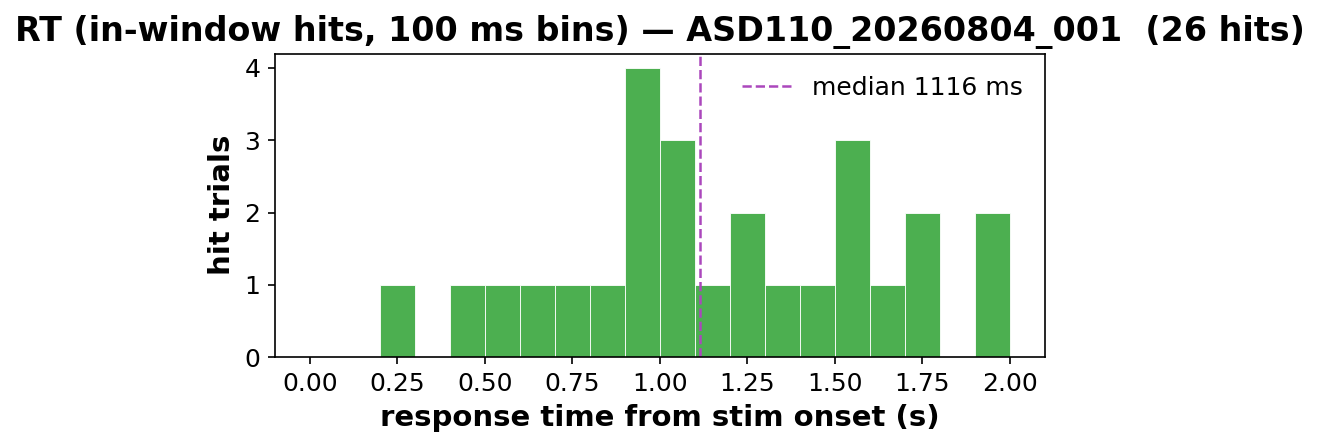

In [104]:
# RT within the response window — in-window HIT trials only, fixed 100 ms bins.
# ("0.1 ms" read as 0.1 s = 100 ms, matching the live experiment-UI histogram and the ~1.4 s window.)
import numpy as np
import matplotlib.pyplot as plt

BIN_S = 0.1                                                      # 100 ms bins
rt = response_times(data_dir, ref="onset", within_window=True)   # first-lick latency; NaN unless in-window
rt_hit = rt[np.isfinite(rt)]                                     # in-window responders = hits

fig, ax = plt.subplots(figsize=(6, 3.2))
if rt_hit.size:
    edges = np.arange(0, rt_hit.max() + BIN_S, BIN_S)
    ax.hist(rt_hit, bins=edges, color="#4caf50", edgecolor="white", linewidth=0.4)
    ax.axvline(np.median(rt_hit), color="#ab47bc", ls="--", lw=1.2,
               label=f"median {np.median(rt_hit)*1e3:.0f} ms")
    ax.legend(frameon=False)
else:
    ax.text(0.5, 0.5, "no in-window hits", ha="center", va="center", transform=ax.transAxes)
ax.set_xlabel("response time from stim onset (s)")
ax.set_ylabel("hit trials")
ax.set_title(f"RT (in-window hits, {int(BIN_S*1e3)} ms bins) — {info['session_id']}  "
             f"({rt_hit.size} hits)")
fig.tight_layout()

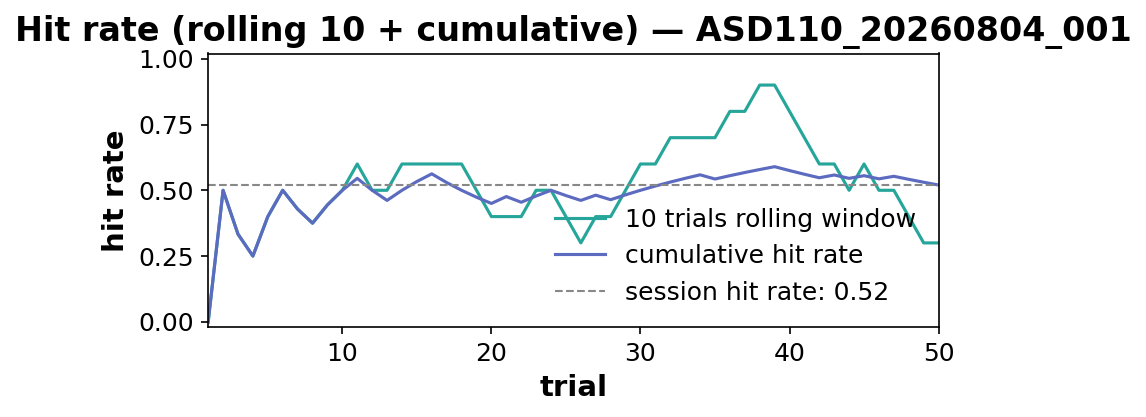

In [105]:
# Rolling + cumulative hit rate. Hit = recorded trial_outcome == "hit" (matches the session hit
# rate reported above). Rolling = trailing WIN-trial mean; cumulative = running mean from trial 1
# (its last point equals the session hit rate).
import numpy as np
import matplotlib.pyplot as plt

WIN = 10
trials = load_trials(data_dir)
hit = (trials["trial_outcome"] == "hit").astype(float)
n = len(hit)
x = np.arange(1, n + 1)
roll = np.array([hit[max(0, i - WIN + 1):i + 1].mean() for i in range(n)])   # trailing rolling mean
cum = np.cumsum(hit) / x                                                     # cumulative mean

fig, ax = plt.subplots(figsize=(6, 3.0))
ax.plot(x, roll, "-", color="#26a69a", lw=1.5, label=f"{WIN} trials rolling window")
ax.plot(x, cum, "-", color="#5c6bc0", lw=1.5, label="cumulative hit rate")
ax.axhline(hit.mean(), color="#888", ls="--", lw=1, label=f"session hit rate: {hit.mean():.2f}")
ax.set_ylim(-0.02, 1.02)
ax.set_xlim(1, max(n, 2))
ax.set_xlabel("trial")
ax.set_ylabel("hit rate")
ax.set_title(f"Hit rate (rolling {WIN} + cumulative) — {info['session_id']}")
ax.legend(frameon=False)
fig.tight_layout()
# For a go/nogo task, restrict to GO trials for a true hit rate, e.g.:
#   go = trials["stim_az_deg"] < 0            # go_rule 'left' (az<0 = go); adjust per go_rule
#   hit = ((trials["trial_outcome"] == "hit") & go)[go].astype(float)  # then roll over go trials